# Data Wrangling

**Thời gian ước tính / Estimated time:** 40–50 phút

**Data wrangling** là quá trình **làm sạch, sắp xếp và biến đổi** dữ liệu thô (lộn xộn) thành bảng **dùng được** cho phân tích hoặc mô hình.

Data wrangling turns raw, messy data into a consistent table you can analyze.

Notebook này làm trên bộ **Auto MPG** (xe hơi). Mỗi bước: *vì sao* → *làm sao* → *hay nhầm*.

## Mục tiêu / Objectives

Sau khi làm xong bạn sẽ:

* Phát hiện kiểu sai, ký hiệu thiếu (`"?"`), cột phân loại giả số
* Xử lý missing (mean / mode / drop) **đúng loại cột**
* Ép kiểu, đổi đơn vị, đưa về thang 0–1, chia bin, tạo dummy 0/1
* Lưu file sạch (`to_csv`)

## Mục lục / Table of Contents

1. [Các bước wrangling](#steps)
2. [Download data and explore](#load)
3. [Missing values](#missing)
4. [Đúng kiểu dữ liệu](#dtype)
5. [Standardization (đơn vị)](#std)
6. [Normalization (thang đo)](#norm)
7. [Binning](#bin)
8. [Dummy variables](#dummy)
9. [Check and save](#save)


## 1. Các bước wrangling <a id="steps"></a>

| Bước / Step | Việc làm |
|---|---|
| **Discovery** | Xem `head`, `info`, `dtypes`, missing, giá trị lạ |
| **Structuring** | Cùng một bảng, tên cột rõ, mỗi cột một nghĩa |
| **Cleaning** | Trùng, sai, thiếu, outlier |
| **Enriching** | Cột mới (đổi đơn vị, bin, dummy) |
| **Validating** | `isnull().sum()`, `dtypes` lại lần nữa |
| **Publishing** | `to_csv` / đưa vào mô hình |

Sáu kỹ thuật dưới đây là phần **cleaning + enriching** hay gặp nhất trên bảng số.


### Sáu kỹ thuật sẽ làm trên Auto.csv

**1. Missing values**  
Ký hiệu thiếu (`"?"`, `"NA"`, `""`) phải thành `NaN` thì pandas mới đếm và thay được.  
- Cột **số**, thiếu ít, cột không phải target → thường **mean** (hoặc median nếu lệch).  
- Cột **chữ / nhóm** → **mode**.  
- Thiếu **target** hoặc thiếu quá nhiều → **drop** dòng/cột, rồi `reset_index`.

**2. Correct data format**  
`df.dtypes`: số bị đọc thành `object` vì có `"?"`. Sau khi thành `NaN` + điền số → `.astype(float)`.

**3. Standardization (đơn vị đo)**  
Cùng một đại lượng, **cùng đơn vị** (mpg vs L/100km). *Không* phải trừ mean chia std.

**4. Normalization (thang 0–1)**  
Cột `weight` (hàng nghìn) không nên át `mpg` (vài chục) trong một số mô hình. `x / x.max()` đưa về 0–1. **Giữ cột gốc** để còn giải thích.

**5. Binning**  
Số liên tục → nhóm Low/Medium/High (`pd.cut`) cho bảng tần suất, bar, hoặc mô hình cần nhóm.

**6. Dummy variables**  
Nhóm chữ (USA/Europe/Japan) → cột 0/1. Máy học không “hiểu” chữ trên cột `origin`.


## 2. Download data and explore <a id="load"></a>

Luôn bắt đầu bằng **nhìn dữ liệu**, đừng nhảy vào `fillna`. Hỏi: bao nhiêu dòng? cột nào object? có `"?"` không?


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url = "https://github.com/pykale/transparentML/raw/main/data/Auto.csv"
df = pd.read_csv(url)
print("shape:", df.shape)
df.head()


shape: (397, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


### Từ điển cột — Auto MPG (~1970–1982)

| Cột | Kiểu lúc đọc | Ý nghĩa |
|---|---|---|
| `mpg` | float | Miles per gallon — càng cao càng tiết kiệm |
| `cylinders` | int | Số xi-lanh (3–8), thực chất là **nhóm** dạng số |
| `displacement` | float | Dung tích xy-lanh (cubic inches) |
| `horsepower` | **object** | Mã lực — **nên là số**; đang là chuỗi vì có `"?"` |
| `weight` | int | Trọng lượng (pounds) |
| `acceleration` | float | Giây tăng tốc 0–60 mph; số nhỏ = nhanh hơn |
| `year` | int | Năm (70–82 = 1970–1982) |
| `origin` | int | `1` Mỹ, `2` Âu, `3` Nhật — **phân loại giả số** |
| `name` | object | Tên xe |

**Việc wrangling sẽ chạm:** `horsepower` (`?` + kiểu), `mpg` (đổi đơn vị), `weight`/`displacement`/`horsepower` (0–1), `horsepower` (bin), `origin` (dummy).


In [2]:
# Discovery: kiểu, thống kê, horsepower đang chứa gì
print("----- dtypes -----")
print(df.dtypes)
print("\n----- describe (chỉ cột số) -----")
print(df.describe())
print("\n----- horsepower: vài giá trị (gồm '?' nếu có) -----")
print(df["horsepower"].unique()[:15])
print("số dòng horsepower == '?':", (df["horsepower"] == "?").sum())


----- dtypes -----
mpg             float64
cylinders         int64
displacement    float64
horsepower       object
weight            int64
acceleration    float64
year              int64
origin            int64
name             object
dtype: object

----- describe (chỉ cột số) -----
              mpg   cylinders  displacement       weight  acceleration  \
count  397.000000  397.000000    397.000000   397.000000    397.000000   
mean    23.515869    5.458438    193.532746  2970.261965     15.555668   
std      7.825804    1.701577    104.379583   847.904119      2.749995   
min      9.000000    3.000000     68.000000  1613.000000      8.000000   
25%     17.500000    4.000000    104.000000  2223.000000     13.800000   
50%     23.000000    4.000000    146.000000  2800.000000     15.500000   
75%     29.000000    8.000000    262.000000  3609.000000     17.100000   
max     46.600000    8.000000    455.000000  5140.000000     24.800000   

             year      origin  
count  397.000000

`describe()` **bỏ** cột `object`, nên `horsepower` chưa ra mean. Đó là tín hiệu: cột số đang bị coi là chữ.

`describe()` skips object columns — another hint that `horsepower` is not numeric yet.


## 3. Missing values <a id="missing"></a>

### 3.1. Vì sao `"?"` chưa phải missing?

Pandas chỉ coi `NaN` là thiếu. `"?"` là **chuỗi**, nên `isnull()` = False. Phải `.replace("?", np.nan)` trước.

### 3.2. Chọn cách xử lý

| Cách | Khi nào | Lưu ý |
|---|---|---|
| **Mean / median** | Cột số, thiếu **ít**, không phải target | Mean bị kéo nếu lệch; median bền hơn |
| **Mode** | Cột nhóm / chữ | Lấy giá trị xuất hiện nhiều nhất |
| **Drop dòng** | Thiếu target, hoặc thiếu quá nhiều ô trên dòng đó | Mất dữ liệu; `reset_index(drop=True)` |
| **Drop cột** | Một cột thiếu gần hết | Mất biến |

Ở đây: 5 `"?"` trên ~397 dòng (~1%), `horsepower` là **số**, `mpg` (target kiểu phân tích) không thiếu → **mean**, không drop.

Không dùng mode vì không có cột chữ bị thiếu. Không drop vì 5 dòng vẫn dùng được sau khi điền.


In [3]:
df.replace("?", np.nan, inplace=True)

print("Số NaN mỗi cột (sau replace):")
print(df.isnull().sum())

print("\nhorsepower — False = không thiếu, True = thiếu:")
print(df["horsepower"].isnull().value_counts())

# astype(float) trước mean vì cột vẫn đang object (NaN + số dạng chữ)
avg_hp = df["horsepower"].astype(float).mean()
print(f"\nMean horsepower (bỏ NaN khi tính mean): {avg_hp:.2f}")

df["horsepower"] = df["horsepower"].fillna(avg_hp)

print("\nNaN sau khi điền:")
print(df.isnull().sum())


Số NaN mỗi cột (sau replace):
mpg             0
cylinders       0
displacement    0
horsepower      5
weight          0
acceleration    0
year            0
origin          0
name            0
dtype: int64

horsepower — False = không thiếu, True = thiếu:
horsepower
False    392
True       5
Name: count, dtype: int64

Mean horsepower (bỏ NaN khi tính mean): 104.47

NaN sau khi điền:
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
year            0
origin          0
name            0
dtype: int64


**Hay nhầm**

* `fillna` trước khi `replace("?")` → `"?"` vẫn còn, mean không chạy hoặc sai.
* `mean()` trên object không có `"?"` đã replace nhưng chưa `astype` → lỗi / kết quả lạ.
* Điền mean cho **cột nhóm** (origin) → vô nghĩa (1.7 không phải Mỹ/Âu/Nhật).

We replace `"?"` first, then take the mean on a numeric series, then fill.


## 4. Đúng kiểu dữ liệu <a id="dtype"></a>

`df.dtypes` phải khớp **nghĩa** cột: đo lường → `float`/`int`; tên → `object`; nhóm mã hoá → sau này dummy.

`horsepower` còn `object` vì lúc đọc CSV có `"?"`. Đã thành số thật (điền mean) thì ép `float`.


In [4]:
print("Trước astype:")
print(df.dtypes)
print()

df["horsepower"] = df["horsepower"].astype(float)

print("Sau astype (horsepower phải là float64):")
print(df.dtypes)


Trước astype:
mpg             float64
cylinders         int64
displacement    float64
horsepower       object
weight            int64
acceleration    float64
year              int64
origin            int64
name             object
dtype: object

Sau astype (horsepower phải là float64):
mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
year              int64
origin            int64
name             object
dtype: object


**Kiểm tra:** `horsepower` = `float64`. Các cột int/float khác giữ nguyên. `name` vẫn object.

**Hay nhầm:** `astype(int)` khi còn NaN → lỗi. Điền hoặc drop trước. Ở đây đã fillna nên `float` an toàn (`int` cũng được nếu không cần phần thập phân của mean).


## 5. Standardization — cùng đơn vị đo <a id="std"></a>

**Standardization ở đây = đổi đơn vị**, để so sánh / báo cáo theo chuẩn quen dùng.

Không nhầm với *standardize thống kê* \(z = (x-\mu)/\sigma\).

`mpg` (dặm/gallon) là đơn vị Mỹ. Nhiều nước dùng **L/100km** (số **càng nhỏ** càng tiết kiệm — **ngược chiều** mpg).

Công thức hay dùng: `L/100km ≈ 235 / mpg`.

Giữ cột `mpg` gốc; thêm cột mới, không ghi đè nếu còn cần mpg.


In [5]:
df["L/100km"] = 235 / df["mpg"]
df[["mpg", "L/100km"]].head()


,mpg,L/100km
0,18.0,13.055556
1,15.0,15.666667
2,18.0,13.055556
3,16.0,14.687500
4,17.0,13.823529


**Đọc bảng:** mpg cao → L/100km thấp (xe tiết kiệm). Đó là dấu hiệu công thức đúng chiều.

**Hay nhầm:** ghi đè `mpg` rồi không giải thích được “miles per gallon” nữa; nhân nhầm hằng số; tưởng bước này đã đưa cột về 0–1 (đó là bước sau).


## 6. Normalization — cùng thang đo <a id="norm"></a>

`weight` ~ 2000–5000, `mpg` ~ 10–40. Một số thuật toán (khoảng cách, gradient) bị cột **số lớn** lấn.

Đưa về khoảng **0–1** bằng chia max (simple max scaling):

\[
x_{\mathrm{norm}} = x / x_{\max}
\]

Min–max đầy đủ là \((x - x_{\min})/(x_{\max}-x_{\min})\) — cũng về 0–1, min được kéo về 0. Lab này dùng `/ max` cho gọn.

**Giữ cột gốc.** Cột `*_normalized` chỉ để mô hình / so sánh thang; báo cáo vẫn dùng pound, mã lực.


In [6]:
df["weight_normalized"] = df["weight"] / df["weight"].max()
df["displacement_normalized"] = df["displacement"] / df["displacement"].max()
df["horsepower_normalized"] = df["horsepower"] / df["horsepower"].max()

df[["weight", "weight_normalized",
    "displacement", "displacement_normalized",
    "horsepower", "horsepower_normalized"]].head()


,weight,weight_normalized,displacement,displacement_normalized,horsepower,horsepower_normalized
0,3504,0.681712,307.0,0.674725,130.0,0.565217
1,3693,0.718482,350.0,0.769231,165.0,0.717391
2,3436,0.668482,318.0,0.698901,150.0,0.652174
3,3433,0.667899,304.0,0.668132,150.0,0.652174
4,3449,0.671012,302.0,0.663736,140.0,0.608696


**Đọc bảng:** giá trị gốc hàng nghìn; cột norm ∈ (0, 1]. Xe nặng nhất có `weight_normalized = 1`.

**Hay nhầm:** normalize cả dummy 0/1 (không cần); normalize rồi **xoá** cột gốc; normalize `year`/`origin` như biến liên tục liên tục mà không suy nghĩ (origin là nhóm).


## 7. Binning — cắt số thành nhóm <a id="bin"></a>

**Binning** = cắt một cột **số** thành vài **khoảng**, rồi gắn nhãn chữ (Low / Medium / High).

Dùng khi muốn bảng tần suất / bar theo nhóm, hoặc luật kiểu “xe công suất cao”.

### Cắt thế nào? 4 cạnh → 3 nhóm

`horsepower` chạy từ **min** đến **max** (khoảng 46 → 230). Muốn **3 nhóm** thì cần **4 mốc** trên trục số — như 3 phòng cần 4 bức tường:

```
min ≈ 46          107.3           168.7          max ≈ 230
     |---------------|---------------|---------------|
           Low            Medium           High
        (bin 1)          (bin 2)         (bin 3)
```

`np.linspace(min, max, 4)` **không** tạo 4 nhóm. Số `4` là số **cạnh**. Số nhóm = số cạnh − 1 = 3.

Ba khoảng **bằng nhau trên trục hp** (cùng độ rộng ≈ (230−46)/3 ≈ 61), **không** bằng nhau về số xe.

| Nhóm | Khoảng (gần đúng) | Ví dụ |
|---|---|---|
| Low | [46 , 107.3] | 80 hp → Low |
| Medium | (107.3 , 168.7] | 130 hp → Medium |
| High | (168.7 , 230] | 200 hp → High |

`pd.cut(..., include_lowest=True)` để **cả xe min = 46** cũng vào Low (không bị NaN).

Histogram phải dùng **đúng mảng `bins` đã cut** — không ghi `bins=3` kiểu khác, hai hình mới khớp.


Mốc cắt (cạnh bin): [ 46.         107.33333333 168.66666667 230.        ]

Số xe mỗi nhóm:
horsepower_binned
Low       262
Medium    103
High       32
Name: count, dtype: int64


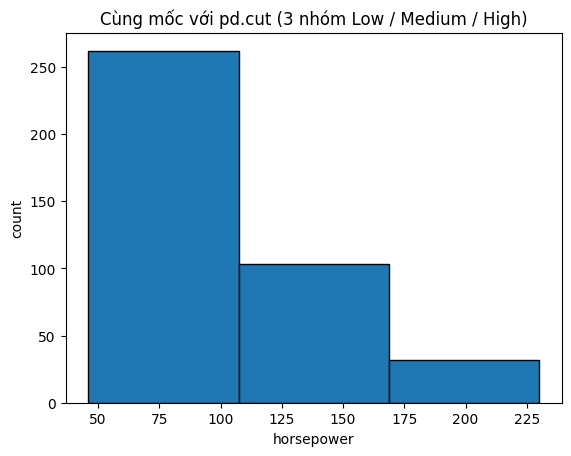

,horsepower,horsepower_binned
0,130.0,Medium
1,165.0,Medium
2,150.0,Medium
3,150.0,Medium
4,140.0,Medium


In [7]:
bins = np.linspace(df["horsepower"].min(), df["horsepower"].max(), 4)
group_names = ["Low", "Medium", "High"]
print("Mốc cắt (cạnh bin):", bins)

df["horsepower_binned"] = pd.cut(
    df["horsepower"], bins, labels=group_names, include_lowest=True
)

print("\nSố xe mỗi nhóm:")
print(df["horsepower_binned"].value_counts().sort_index())

plt.hist(df["horsepower"], bins=bins, edgecolor="black")
plt.xlabel("horsepower")
plt.ylabel("count")
plt.title("Cùng mốc với pd.cut (3 nhóm Low / Medium / High)")
plt.show()

df[["horsepower", "horsepower_binned"]].head()


**Đọc output**

* Dòng `4 cạnh`: bốn số. Đó là chỗ **cắt**, không phải nhãn.
* `value_counts`: Low thường đông hơn High — bin **cùng rộng** ≠ cùng số xe (nhiều xe nhỏ hp).
* `head`: 130, 165, 150 đều **Medium** vì nằm giữa cạnh 2 và cạnh 3.
* Hist: **ba cột** = ba nhóm; trục X vẫn là horsepower thật.

**Hay nhầm**

* `linspace(..., 4)` tưởng ra **4 nhóm** → thực ra 4 cạnh = 3 nhóm. Muốn *k* nhóm thì `linspace(..., k+1)`.
* So sánh mean giữa bin như thể mỗi bin “cùng ý nghĩa thống kê” — chỉ cùng **độ rộng hp**.
* Nhãn ngược: `labels` phải theo thứ tự bin từ trái sang phải (thấp → cao).


## 8. Dummy variables (biến giả 0/1) <a id="dummy"></a>

`origin` = 1, 2, 3 **không phải** “Nhật gấp 3 Mỹ”. Đó là **mã nhóm**. Đưa vào hồi quy như số sẽ sai nghĩa.

Cách làm:

1. Đổi mã → tên (`map`) cho dễ đọc.
2. `pd.get_dummies(..., dtype=int)` → mỗi nhóm một cột 0/1.
3. `concat` vào `df`, **xoá cột gốc** (tránh vừa chữ vừa dummy).

Một dòng chỉ một origin → đúng **một** cột dummy = 1, các cột kia = 0.

*(Nâng cao: hồi quy tuyến tính có intercept đôi khi bỏ 1 cột dummy — dummy trap. Lab này giữ đủ 3 cột để bảng dễ đọc.)*


In [8]:
df["origin"] = df["origin"].map({1: "USA", 2: "Europe", 3: "Japan"})
print("origin sau map:")
print(df["origin"].value_counts())

dummy_origin = pd.get_dummies(df["origin"], prefix="origin", dtype=int)
print("\nCác cột dummy:")
print(dummy_origin.head())

df = pd.concat([df, dummy_origin], axis=1)
df.drop("origin", axis=1, inplace=True)

df.head()


origin sau map:
origin
USA       248
Japan      79
Europe     70
Name: count, dtype: int64

Các cột dummy:
   origin_Europe  origin_Japan  origin_USA
0              0             0           1
1              0             0           1
2              0             0           1
3              0             0           1
4              0             0           1


,mpg,cylinders,displacement,horsepower,weight,acceleration,year,name,L/100km,weight_normalized,displacement_normalized,horsepower_normalized,horsepower_binned,origin_Europe,origin_Japan,origin_USA
0,18.0,8,307.0,130.0,3504,12.0,70,chevrolet chevelle malibu,13.055556,0.681712,0.674725,0.565217,Medium,0,0,1
1,15.0,8,350.0,165.0,3693,11.5,70,buick skylark 320,15.666667,0.718482,0.769231,0.717391,Medium,0,0,1
2,18.0,8,318.0,150.0,3436,11.0,70,plymouth satellite,13.055556,0.668482,0.698901,0.652174,Medium,0,0,1
3,16.0,8,304.0,150.0,3433,12.0,70,amc rebel sst,14.687500,0.667899,0.668132,0.652174,Medium,0,0,1
4,17.0,8,302.0,140.0,3449,10.5,70,ford torino,13.823529,0.671012,0.663736,0.608696,Medium,0,0,1


**Đọc `head`:** thấy `origin_USA`, `origin_Europe`, `origin_Japan` ∈ {0, 1}. Cộng 3 cột trên một dòng = 1.

**Hay nhầm:** để `origin` số 1–2–3 trong mô hình; `get_dummies` rồi **không** drop cột chữ; quên `dtype=int` (một số bản pandas ra True/False).


## 9. Check and save <a id="save"></a>

Trước khi `to_csv`:

* `isnull().sum()` còn 0 (hoặc đúng chỗ bạn cố ý để thiếu)
* `horsepower` là số
* có cột mới: `L/100km`, `*_normalized`, `horsepower_binned`, `origin_*`

`index=False` để file không thêm cột index 0,1,2,…


In [9]:
print("NaN còn lại:")
print(df.isnull().sum().sum(), "ô")
print("\nCác cột hiện có:")
print(df.columns.tolist())
print("\nshape:", df.shape)

df.to_csv("clean_df.csv", index=False)
print("Đã lưu clean_df.csv")
df.head()


NaN còn lại:
0 ô

Các cột hiện có:
['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'year', 'name', 'L/100km', 'weight_normalized', 'displacement_normalized', 'horsepower_normalized', 'horsepower_binned', 'origin_Europe', 'origin_Japan', 'origin_USA']

shape: (397, 16)
Đã lưu clean_df.csv


,mpg,cylinders,displacement,horsepower,weight,acceleration,year,name,L/100km,weight_normalized,displacement_normalized,horsepower_normalized,horsepower_binned,origin_Europe,origin_Japan,origin_USA
0,18.0,8,307.0,130.0,3504,12.0,70,chevrolet chevelle malibu,13.055556,0.681712,0.674725,0.565217,Medium,0,0,1
1,15.0,8,350.0,165.0,3693,11.5,70,buick skylark 320,15.666667,0.718482,0.769231,0.717391,Medium,0,0,1
2,18.0,8,318.0,150.0,3436,11.0,70,plymouth satellite,13.055556,0.668482,0.698901,0.652174,Medium,0,0,1
3,16.0,8,304.0,150.0,3433,12.0,70,amc rebel sst,14.687500,0.667899,0.668132,0.652174,Medium,0,0,1
4,17.0,8,302.0,140.0,3449,10.5,70,ford torino,13.823529,0.671012,0.663736,0.608696,Medium,0,0,1


## Tóm tắt / Summary

| Việc đã làm | Cột |
|---|---|
| `"?"` → NaN → mean | `horsepower` |
| `astype(float)` | `horsepower` |
| Đổi đơn vị | `L/100km` từ `mpg` |
| Về 0–1 | `weight`, `displacement`, `horsepower` (cột `*_normalized`) |
| 3 nhóm | `horsepower_binned` |
| Dummy 0/1 | `origin_*` (đã xoá `origin`) |
| Xuất file | `clean_df.csv` |

